<a href="https://colab.research.google.com/github/24tara/Final-Year-Project-Machine-Modelling-of-Credit-Card-Approval-Predictions/blob/main/FYP_Dataset_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Loading


In [54]:
#importing libraries that are relevant, this will allow me to manipulate data and merge tables
import pandas as pd
import numpy
import matplotlib.pyplot as plt
import seaborn as sns
import warnings as wr
from sklearn.neighbors import LocalOutlierFactor
import plotly.express as px
#importing more relevant libraies
from sklearn import preprocessing
label_encoder = preprocessing.LabelEncoder
from sklearn.preprocessing import MinMaxScaler

In [55]:
#naming my file as data1
#read the csv file
data2 = pd.read_csv('/content/dataset2.csv')

## Data understanding

In [56]:
#this function calls the first 10 instances from the dataset
data2.head(10)

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
5,21.0,female,High School,12951.0,0,OWN,2500.0,VENTURE,7.14,0.19,2.0,532,No,1
6,26.0,female,Bachelor,93471.0,1,RENT,35000.0,EDUCATION,12.42,0.37,3.0,701,No,1
7,24.0,female,High School,95550.0,5,RENT,35000.0,MEDICAL,11.11,0.37,4.0,585,No,1
8,24.0,female,Associate,100684.0,3,RENT,35000.0,PERSONAL,8.90,0.35,2.0,544,No,1
9,21.0,female,High School,12739.0,0,OWN,1600.0,VENTURE,14.74,0.13,3.0,640,No,1


In [57]:
data2.shape

(45000, 14)

In [58]:
#this function breaks down the types of data in the dataset
data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [59]:
data2.columns.tolist()

['person_age',
 'person_gender',
 'person_education',
 'person_income',
 'person_emp_exp',
 'person_home_ownership',
 'loan_amnt',
 'loan_intent',
 'loan_int_rate',
 'loan_percent_income',
 'cb_person_cred_hist_length',
 'credit_score',
 'previous_loan_defaults_on_file',
 'loan_status']

In [60]:
data2.describe().T

,count,mean,std,min,25%,50%,75%,max
person_age,45000.0,27.764178,6.045108,20.00,24.00,26.00,30.00,144.00
person_income,45000.0,80319.053222,80422.498632,8000.00,47204.00,67048.00,95789.25,7200766.00
person_emp_exp,45000.0,5.410333,6.063532,0.00,1.00,4.00,8.00,125.00
loan_amnt,45000.0,9583.157556,6314.886691,500.00,5000.00,8000.00,12237.25,35000.00
loan_int_rate,45000.0,11.006606,2.978808,5.42,8.59,11.01,12.99,20.00
loan_percent_income,45000.0,0.139725,0.087212,0.00,0.07,0.12,0.19,0.66
cb_person_cred_hist_length,45000.0,5.867489,3.879702,2.00,3.00,4.00,8.00,30.00
credit_score,45000.0,632.608756,50.435865,390.00,601.00,640.00,670.00,850.00
loan_status,45000.0,0.222222,0.415744,0.00,0.00,0.00,0.00,1.00


## data quality


In [61]:
data2.nunique()

,0
person_age,60
person_gender,2
person_education,5
person_income,33989
person_emp_exp,63
person_home_ownership,4
loan_amnt,4483
loan_intent,6
loan_int_rate,1302
loan_percent_income,64


In [62]:
data2["person_gender"].unique()

array(['female', 'male'], dtype=object)

In [63]:
data2["person_education"].unique()

array(['Master', 'High School', 'Bachelor', 'Associate', 'Doctorate'],
      dtype=object)

In [64]:
data2["person_home_ownership"].unique()

array(['RENT', 'OWN', 'MORTGAGE', 'OTHER'], dtype=object)

In [65]:
data2['loan_intent'].unique()

array(['PERSONAL', 'EDUCATION', 'MEDICAL', 'VENTURE', 'HOMEIMPROVEMENT',
       'DEBTCONSOLIDATION'], dtype=object)

In [66]:
data2['previous_loan_defaults_on_file'].unique()

array(['No', 'Yes'], dtype=object)

In [67]:
data2["loan_status"].unique()

array([1, 0])

In [68]:
data2.isnull().sum()

,0
person_age,0
person_gender,0
person_education,0
person_income,0
person_emp_exp,0
person_home_ownership,0
loan_amnt,0
loan_intent,0
loan_int_rate,0
loan_percent_income,0


## EDA

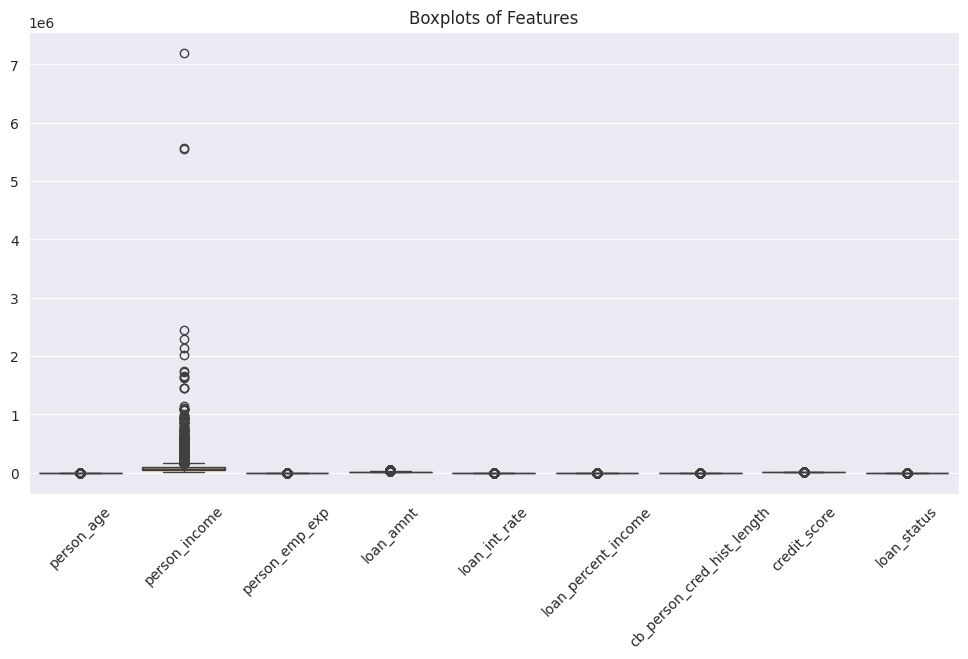

In [69]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=data2)
plt.xticks(rotation=45)
plt.title("Boxplots of Features")
plt.show()

In [70]:
person_age_fig = px.box(data2, y='person_age')
person_age_fig.show()

In [71]:
person_income_fig = px.box(data2, y='person_income')
person_income_fig.show()

In [72]:
person_emp_exp_fig = px.box(data2, y='person_emp_exp')
person_emp_exp_fig.show()

In [73]:
loan_int_rate_fig = px.box(data2, y='loan_int_rate')
loan_int_rate_fig.show()

In [74]:
loan_percent_income_fig = px.box(data2, y='loan_percent_income')
loan_percent_income_fig.show()

In [75]:
cb_person_cred_hist_length_fig = px.box(data2, y='cb_person_cred_hist_length')
cb_person_cred_hist_length_fig.show()

In [76]:
credit_score_fig = px.box(data2, y='credit_score')
credit_score_fig.show()

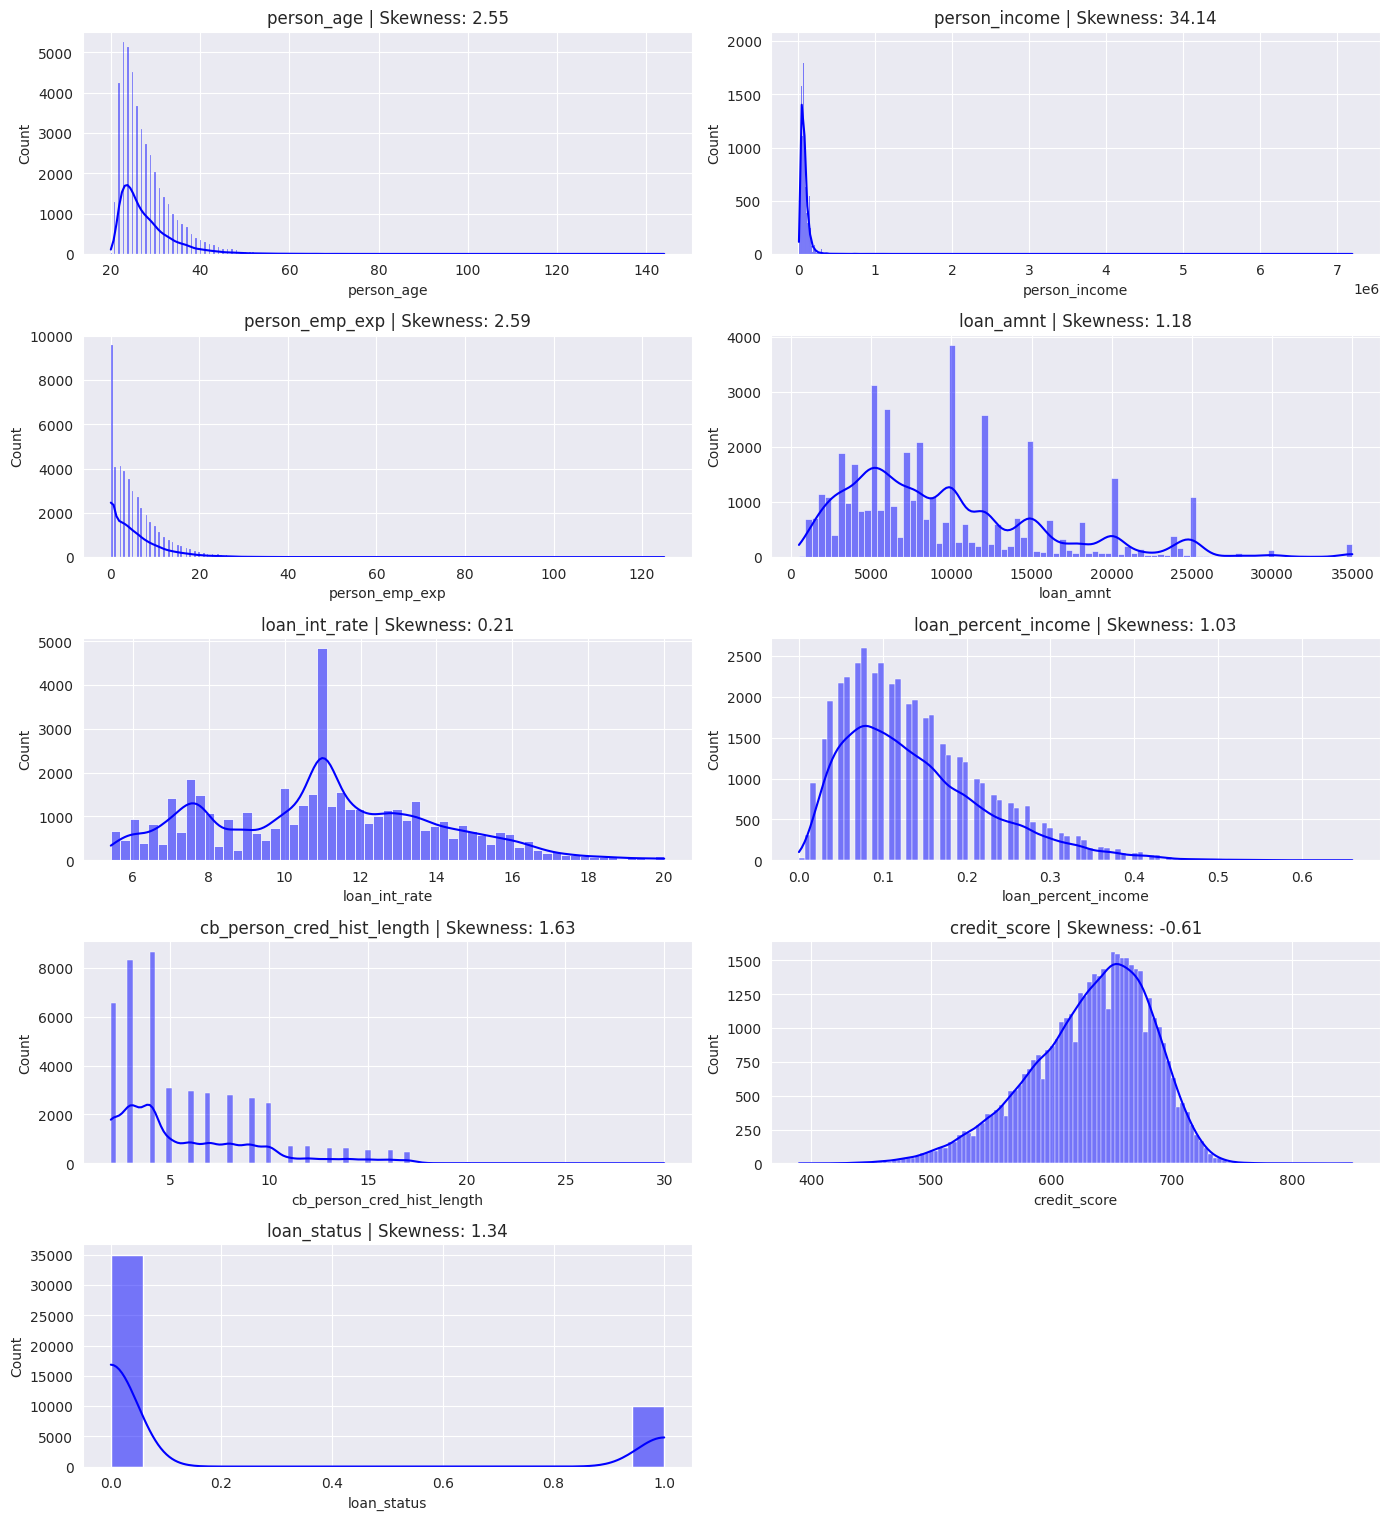

In [77]:
sns.set_style("darkgrid")

numerical_columns = data2.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(14, len(numerical_columns) * 3))
for idx, feature in enumerate(numerical_columns, 1):
    plt.subplot(len(numerical_columns), 2, idx)
    sns.histplot(data2[feature], kde=True)
    plt.title(f"{feature} | Skewness: {round(data2[feature].skew(), 2)}")

plt.tight_layout()
plt.show()

Text(0.5, 0.98, 'Pair Plot for Data2')

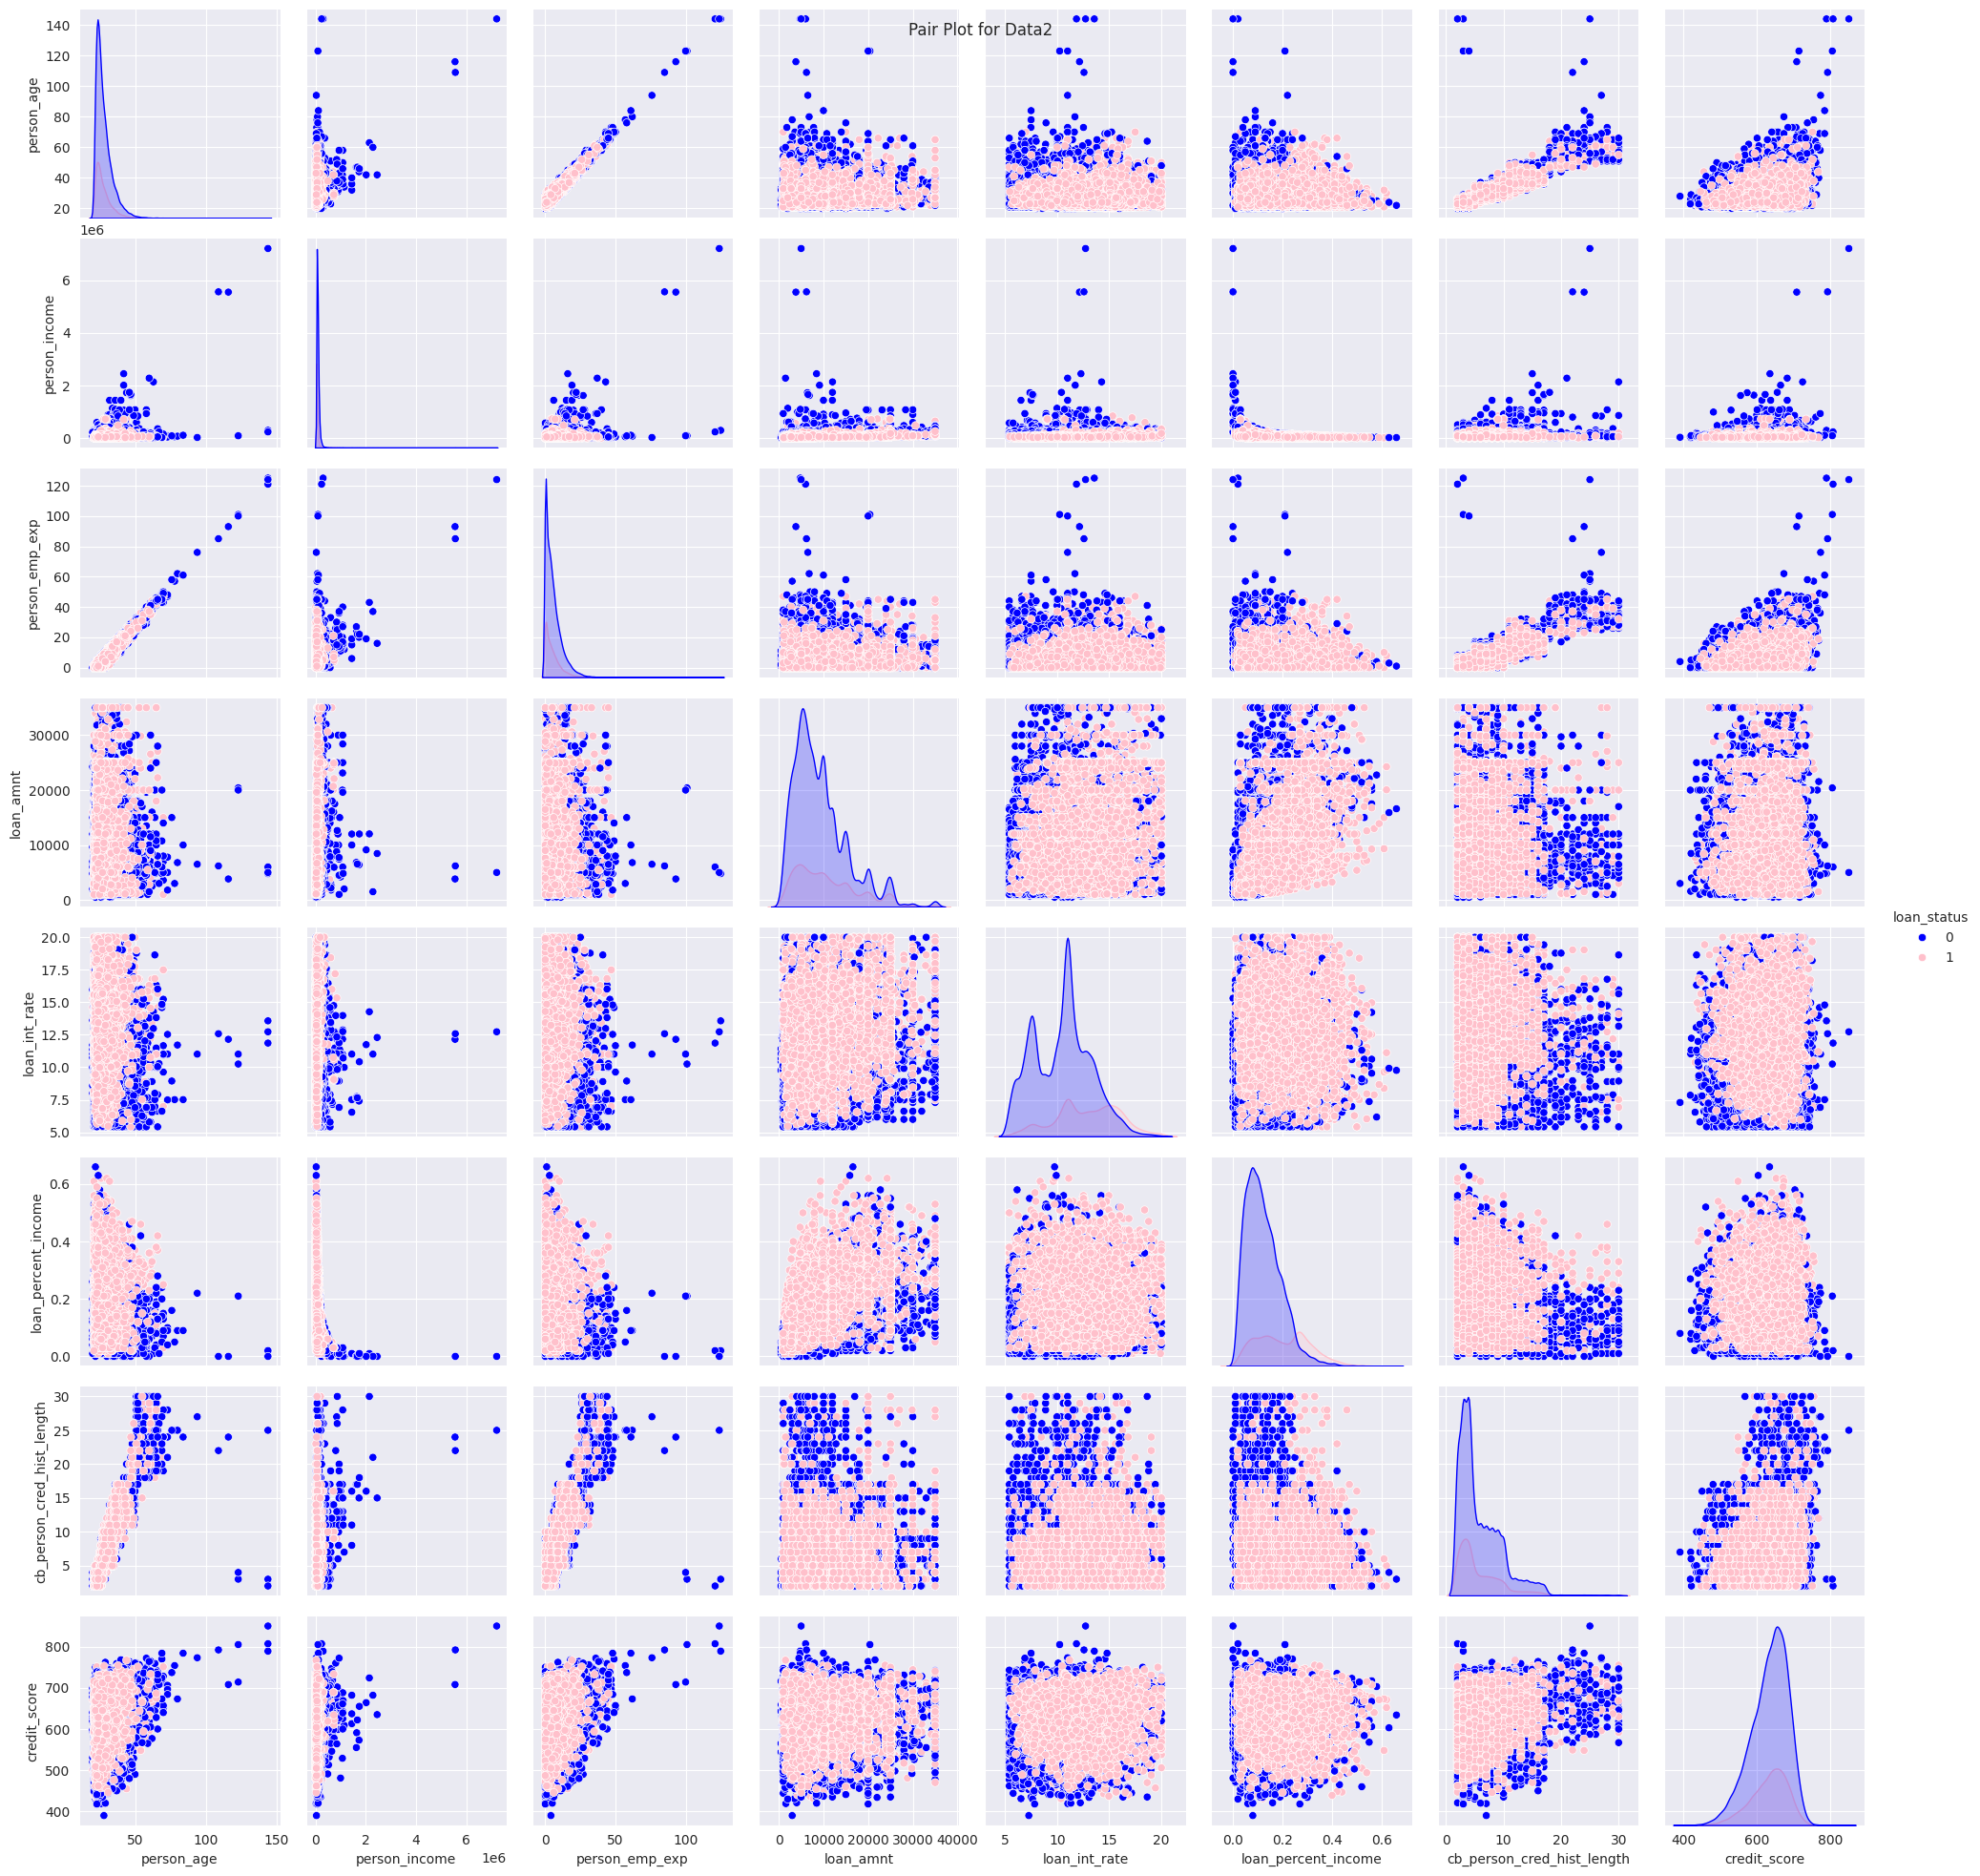

In [78]:
sns.set_palette(("blue","pink"))

sns.pairplot(
    data2,
    hue="loan_status",

)

plt.suptitle('Pair Plot for Data2')

In [79]:
person_gender1_fig = px.bar(data2, x='person_gender')
person_gender1_fig.show()

In [80]:
person_education1_fig = px.bar(data2, x='person_education')
person_education1_fig.show()

In [81]:
person_home_ownership1_fig = px.bar(data2, x='person_home_ownership')
person_home_ownership1_fig.show()

In [82]:
loan_intent1_fig = px.bar(data2, x='loan_intent')
loan_intent1_fig.show()

In [83]:
previous_loan_defaults_on_file1_fig = px.bar(data2, x='previous_loan_defaults_on_file')
previous_loan_defaults_on_file1_fig.show()

In [84]:
#works out ratio for how many people are approved a loan compared to rejected
counts = data2['loan_status'].value_counts()
imbalance_ratio = counts.max() / counts.min()
print(f"Imbalance Ratio: {imbalance_ratio:.2f}:1")

Imbalance Ratio: 3.50:1


# DATA PREPROCESSING

In [85]:
#this is a in built function that detects outliers using IQR
#returns the outliers at the end

def find_outliers_IQR(data):

  q1=data.quantile(0.25)

  q3=data.quantile(0.75)

  IQR=q3-q1

  outliers = data[((data<(q1-1.5*IQR))|(data> (q3+1.5*IQR)))]

  return outliers

In [86]:
#have called outliers by using a function from a numeric variable
#called outliers to the screen
person_age_outliers = find_outliers_IQR(data2['person_age'])

print("number of outliers: "+ str(len(person_age_outliers)))

person_age_outliers

number of outliers: 2188


,person_age
81,144.0
183,144.0
575,123.0
747,123.0
29120,40.0
...,...
44916,42.0
44923,47.0
44947,42.0
44972,43.0


In [87]:
#have called outliers by using a function from a numeric variable
#called outliers to the screen
person_income_outliers = find_outliers_IQR(data2['person_income'])

print("number of outliers: "+ str(len(person_income_outliers)))

person_income_outliers

number of outliers: 2218


,person_income
15,600891.0
20,195718.0
33,368115.0
34,361076.0
42,361293.0
...,...
44831,192090.0
44836,293525.0
44922,726416.0
44947,705960.0


In [88]:
#have called outliers by using a function from a numeric variable
#called outliers to the screen
person_emp_exp_outliers = find_outliers_IQR(data2['person_emp_exp'])

print("number of outliers: "+ str(len(person_emp_exp_outliers)))

person_emp_exp_outliers

number of outliers: 1724


,person_emp_exp
81,125
183,121
575,101
747,100
29120,19
...,...
44916,21
44923,24
44947,21
44972,20


In [89]:
#have called outliers by using a function from a numeric variable
#called outliers to the screen
loan_amnt_outliers = find_outliers_IQR(data2['loan_amnt'])

print("number of outliers: "+ str(len(loan_amnt_outliers)))

loan_amnt_outliers

number of outliers: 2348


,loan_amnt
0,35000.0
3,35000.0
4,35000.0
6,35000.0
7,35000.0
...,...
44922,24890.0
44944,30000.0
44952,24000.0
44970,25000.0


In [90]:
#have called outliers by using a function from a numeric variable
#called outliers to the screen
loan_int_rate_outliers = find_outliers_IQR(data2['loan_int_rate'])

print("number of outliers: "+ str(len(loan_int_rate_outliers)))

loan_int_rate_outliers

number of outliers: 124


,loan_int_rate
17,20.00
112,19.91
349,19.74
420,19.69
440,19.69
...,...
44762,20.00
44850,20.00
44920,19.62
44965,19.80


In [91]:
#have called outliers by using a function from a numeric variable
#called outliers to the screen
loan_percent_income_outliers = find_outliers_IQR(data2['loan_percent_income'])

print("number of outliers: "+ str(len(loan_percent_income_outliers)))

loan_percent_income_outliers

number of outliers: 744


,loan_percent_income
0,0.49
2,0.44
3,0.44
4,0.53
22,0.43
...,...
44940,0.40
44942,0.42
44966,0.43
44986,0.47


In [92]:
#have called outliers by using a function from a numeric variable
#called outliers to the screen
cb_person_cred_hist_length_outliers = find_outliers_IQR(data2['cb_person_cred_hist_length'])

print("number of outliers: "+ str(len(cb_person_cred_hist_length_outliers)))

cb_person_cred_hist_length_outliers

number of outliers: 1366


,cb_person_cred_hist_length
29120,16.0
29125,17.0
29127,16.0
29130,17.0
29133,17.0
...,...
44627,22.0
44705,20.0
44734,16.0
44923,18.0


In [93]:
#have called outliers by using a function from a numeric variable
#called outliers to the screen
credit_score_outliers = find_outliers_IQR(data2['credit_score'])

print("number of outliers: "+ str(len(credit_score_outliers)))

credit_score_outliers

number of outliers: 467


,credit_score
81,789
172,484
183,807
353,491
575,805
...,...
44618,492
44676,462
44754,488
44954,482


In [94]:
#again referncing back to code earlier which showed me data types i have selected a variable that is an object type
label_encoder = preprocessing.LabelEncoder()
#data2['person_age']= label_encoder.fit_transform(data2['person_age'])
#data2['person_income'] = label_encoder.fit_transform(data2['person_income'])
#data2['person_emp_exp'] = label_encoder.fit_transform(data2['person_emp_exp'])
#data2['loan_amnt'] = label_encoder.fit_transform(data2['loan_amnt'])
#data2['loan_int_rate'] = label_encoder.fit_transform(data2['loan_int_rate'])
#data2['loan_percent_income'] = label_encoder.fit_transform(data2['loan_percent_income'])
#data2['cb_person_cred_hist_length'] = label_encoder.fit_transform(data2['cb_person_cred_hist_length'])
#data2['credit_score'] = label_encoder.fit_transform(data2['credit_score'])
#data2['loan_status'] = label_encoder.fit_transform(data2['loan_status'])
data2['person_gender'] = data2['person_gender'].map({'female': 1 , 'male' : 2})
data2['person_education'] = data2['person_education'].map({'Master': 1 , 'High School' : 2 , 'Bachelor' : 3 , 'Associate' : 4 , 'Doctorate' : 5})
data2['person_home_ownership'] = data2['person_home_ownership'].map({'OWN': 1 , 'MORTGAGE' : 2 , 'RENT': 3 , 'OTHER' : 4})
data2['loan_intent'] = data2['loan_intent'].map({'PERSONAL': 1 , 'EDUCATION' : 2 , 'MEDICAL' : 3 , 'VENTURE' : 4 , 'HOMEIMPROVEMENT' : 5 , 'DEBTCONSOLIDATION' : 6})
data2['previous_loan_defaults_on_file'] = data2['previous_loan_defaults_on_file'].map({'Yes': 1 , 'No' : 2 })

In [95]:
data2 = data2[data2["person_age"] <= 100]

In [96]:
data2 = data2[data2["person_emp_exp"] <= 85]

In [97]:
scaler = MinMaxScaler()
#scaling numeric columns
datascaled = ["person_income","person_emp_exp","loan_amnt","loan_int_rate","loan_percent_income"]

data2[datascaled] = scaler.fit_transform(data2[datascaled])

In [98]:
data2.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,1,1,0.026201,0.000000,3,1.000000,1,0.727023,0.742424,3.0,561,2,1
1,21.0,1,2,0.001754,0.000000,1,0.014493,2,0.392318,0.121212,2.0,504,1,0
2,25.0,1,2,0.001818,0.039474,2,0.144928,3,0.510974,0.666667,3.0,635,2,1
3,23.0,1,3,0.029399,0.000000,3,1.000000,3,0.672840,0.666667,2.0,675,2,1
4,24.0,2,1,0.023819,0.013158,3,1.000000,3,0.606996,0.803030,4.0,586,2,1


In [99]:
data2.shape

(44993, 14)

# saving dataset


In [100]:
#filterinng the rejected people
rejected_data = data2[data2['loan_status']== 0]
#saving my work, filtered only rejected people
#change name of file
rejected_data.to_csv(r'final_cleaned_filtered_data2.csv', index=False)

In [101]:
#saving my work
#change name of file
rejected_data.to_csv(r'final_cleaned_filtered_data2.csv', index=False)